# Segmentação de Clientes com Técnicas de Clusterização

Este notebook apresenta uma análise de segmentação aplicada aos dados de satisfação de clientes, com o objetivo de identificar grupos com diferentes padrões de comportamento e níveis de criticidade operacional.

A formação dos clusters considera informações relacionadas ao perfil do cliente, características do pedido, entrega e atendimento, sem utilizar diretamente o NPS durante o treinamento dos modelos.

Serão comparados os algoritmos K-Means, DBSCAN e Clusterização Hierárquica, utilizando PCA e Kernel PCA como técnicas de redução de dimensionalidade.

A avaliação será realizada por meio do Silhouette Score, da distribuição dos clientes entre os grupos e da capacidade de gerar segmentos consistentes e úteis para o negócio.

> A proposta não é reproduzir diretamente as categorias tradicionais do NPS, mas identificar perfis de clientes que demandam diferentes níveis de atenção, acompanhamento e atuação.

## 1. Importação das bibliotecas

Nesta etapa, serão importadas as bibliotecas utilizadas para manipulação e visualização dos dados, pré-processamento, redução de dimensionalidade, treinamento dos modelos de clusterização e avaliação dos resultados.

In [1]:
# ================================
# Manipulação de dados
# ================================
import numpy as np
import pandas as pd

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Divisão dos Dados
# ================================
from sklearn.model_selection import train_test_split

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ================================
# Redução de dimensionalidade
# ================================
from sklearn.decomposition import PCA

# ================================
# Modelos de clusterização
# ================================
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans
)

# ================================
# Avaliação dos clusters
# ================================
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score
)

# ================================
# Análise hierárquica e dendrograma
# ================================
from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

# ================================
# Busca de vizinhos para o DBSCAN
# ================================
from sklearn.neighbors import NearestNeighbors

# ================================
# Salvamento dos artefatos
# ================================
import joblib

## 2. Leitura e validação da base

Nesta etapa, será carregada a base previamente tratada, contendo 2.500 registros e 15 variáveis relacionadas ao perfil dos clientes, pedidos, entrega, atendimento e satisfação.

Também serão verificadas a estrutura dos dados, os tipos das colunas e a presença de valores ausentes ou duplicados. A validação confirmou que a base está consistente e adequada para seguir para as etapas de seleção das variáveis, pré-processamento e clusterização.

In [2]:
dados = pd.read_csv('/content/clientes_tratados.csv')
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


In [3]:
print(f'Total de Linhas: {dados.shape[0]}')
print(f'Total de Colunas: {dados.shape[1]}')

Total de Linhas: 2500
Total de Colunas: 15


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade_cliente         2500 non-null   int64  
 1   regiao_cliente        2500 non-null   object 
 2   tempo_cliente_meses   2500 non-null   int64  
 3   valor_pedido          2500 non-null   float64
 4   quantidade_itens      2500 non-null   int64  
 5   valor_desconto        2500 non-null   float64
 6   parcelas_pagamento    2500 non-null   int64  
 7   tempo_entrega_dias    2500 non-null   int64  
 8   atraso_entrega_dias   2500 non-null   int64  
 9   valor_frete           2500 non-null   float64
 10  tentativas_entrega    2500 non-null   int64  
 11  contatos_atendimento  2500 non-null   int64  
 12  tempo_resolucao_dias  2500 non-null   int64  
 13  nps                   2500 non-null   float64
 14  numero_reclamacoes    2500 non-null   int64  
dtypes: float64(4), int64(

In [5]:
print(f'Valores Ausentes: {dados.isna().sum().sum()}')
print(f'Valores Duplicados: {dados.duplicated().sum()}')

Valores Ausentes: 0
Valores Duplicados: 0


## 3. Engenharia de atributos

Nesta etapa, foram criadas três variáveis derivadas a partir de padrões observados na jornada do cliente: atraso crítico na entrega, problema complexo de atendimento e reclamação recorrente.

Esses atributos resumem situações operacionais relevantes e ajudam os modelos de clusterização a identificar grupos com comportamentos mais semelhantes, especialmente em relação à necessidade de acompanhamento e atenção.

In [6]:
dados['atraso_critico'] = (dados['atraso_entrega_dias'] >= 2).astype(int)

dados['problema_complexo'] = (
    (dados['contatos_atendimento'] >= 2) &
    (dados['tempo_resolucao_dias'] >= 3)
).astype(int)

dados['reclamacao_recorrente'] = (dados['numero_reclamacoes'] >= 3).astype(int)

## 4. Divisão dos dados

Nesta etapa, a variável `nps` será retirada da base utilizada na clusterização, pois o objetivo é formar os grupos sem utilizar diretamente a informação de satisfação.

Em seguida, os dados serão divididos em conjuntos de treino e teste. O conjunto de treino será utilizado para ajustar o pré-processamento, as técnicas de redução de dimensionalidade e os modelos, enquanto o conjunto de teste será preservado para análises complementares e verificação da consistência dos resultados.

In [7]:
X = dados.drop('nps', axis=1)

In [8]:
X_treino, X_teste = train_test_split(X, test_size=0.2, random_state=42)

In [9]:
dados_treino = X_treino.copy()

## 5. Pré-processamento dos dados

Nesta etapa, as variáveis numéricas serão padronizadas com `StandardScaler`, garantindo que todas contribuam de forma equilibrada para os cálculos de distância utilizados pelos modelos de clusterização.

A variável categórica `regiao_cliente` será transformada com `OneHotEncoder`, permitindo sua utilização pelos algoritmos sem impor uma relação de ordem entre as categorias.

O pré-processamento será ajustado apenas com os dados de treino e, em seguida, aplicado ao conjunto de teste, mantendo consistência entre as duas bases e evitando vazamento de informação.

In [10]:
col_numericas = ['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias',
                  'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente']
col_categoricas = ['regiao_cliente']

In [11]:
full_pipeline = ColumnTransformer([
    ("num", StandardScaler(), col_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False), col_categoricas)
])

In [12]:
x_treino_tratado = full_pipeline.fit_transform(X_treino)
x_teste_tratado = full_pipeline.transform(X_teste)

In [13]:
num_cols = list(col_numericas)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(col_categoricas)

X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [14]:
X_treino.head()

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,1.581819,-1.116248,0.588739,1.515765,-0.757148,-0.931253,-0.808767,0.565695,0.308458,-0.010428,0.407432,1.313768,-0.068987,0.745124,1.39171,0.460566,1.0,0.0,0.0,0.0
1,1.514946,-1.407271,-0.947281,0.922278,-0.314140,0.329540,-1.606368,-0.128835,1.683501,-1.237234,0.407432,-0.432103,-0.068987,0.745124,1.39171,0.460566,0.0,0.0,0.0,1.0
2,-1.427476,-1.087146,-0.937600,0.922278,0.711398,0.959936,-0.542900,-0.128835,0.830427,1.216379,-0.409065,-1.596017,0.491885,0.745124,-0.71854,0.460566,0.0,0.0,0.0,1.0
3,0.578721,0.920913,-0.625324,1.515765,2.251234,0.014342,-0.011166,-0.823365,1.164852,-1.237234,-1.225562,1.604746,-0.629859,-1.342058,-0.71854,0.460566,1.0,0.0,0.0,0.0
4,0.913087,-0.388690,-0.737362,-0.264695,0.639091,0.014342,0.254700,1.954754,0.900133,-0.010428,3.673419,-0.723081,3.296243,0.745124,1.39171,0.460566,0.0,0.0,0.0,1.0


## 6. Redução de dimensionalidade com PCA

Nesta etapa, o PCA será aplicado para reduzir a quantidade de variáveis e concentrar a maior parte da informação em um número menor de componentes principais.

Inicialmente, todas as componentes foram analisadas por meio da variância explicada individual e acumulada. A análise mostrou que 13 componentes seriam necessárias para ultrapassar 90% da variância total.

Entretanto, a partir da 13ª componente foi observada uma redução mais acentuada na contribuição individual. Por esse motivo, foram selecionadas 12 componentes, responsáveis por preservar aproximadamente 88,16% da variância dos dados.

Essa escolha representa um equilíbrio entre redução de dimensionalidade e retenção de informação, evitando manter uma componente adicional com baixo ganho explicativo.

In [15]:
# ================================
# Aplicação inicial do PCA
# ================================
pca_completo = PCA()

X_treino_pca_completo = pca_completo.fit_transform(
    X_treino
)

X_teste_pca_completo = pca_completo.transform(
    X_teste
)

In [16]:
# ================================
# Cálculo da variância explicada
# ================================
variancia_explicada = pca_completo.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

resultado_pca = pd.DataFrame({
    "componente": np.arange(1, len(variancia_explicada) + 1),
    "variancia_explicada": variancia_explicada,
    "variancia_acumulada": variancia_acumulada
})

resultado_pca

,componente,variancia_explicada,variancia_acumulada
0,1,0.166585,0.166585
1,2,0.109647,0.276232
2,3,0.069316,0.345548
3,4,0.066636,0.412184
4,5,0.063757,0.475941
5,6,0.062169,0.538110
6,7,0.059803,0.597913
7,8,0.059434,0.657347
8,9,0.057990,0.715337
9,10,0.056556,0.771893


In [17]:
# ================================
# Quantidade de componentes para 90%
# ================================
componentes_90 = np.argmax(
    variancia_acumulada >= 0.90
) + 1

variancia_atingida_90 = variancia_acumulada[
    componentes_90 - 1
]

print(
    f"Quantidade de componentes para atingir pelo menos 90% "
    f"da variância: {componentes_90}"
)

print(
    f"Variância acumulada atingida: "
    f"{variancia_atingida_90:.2%}"
)

Quantidade de componentes para atingir pelo menos 90% da variância: 13
Variância acumulada atingida: 91.88%


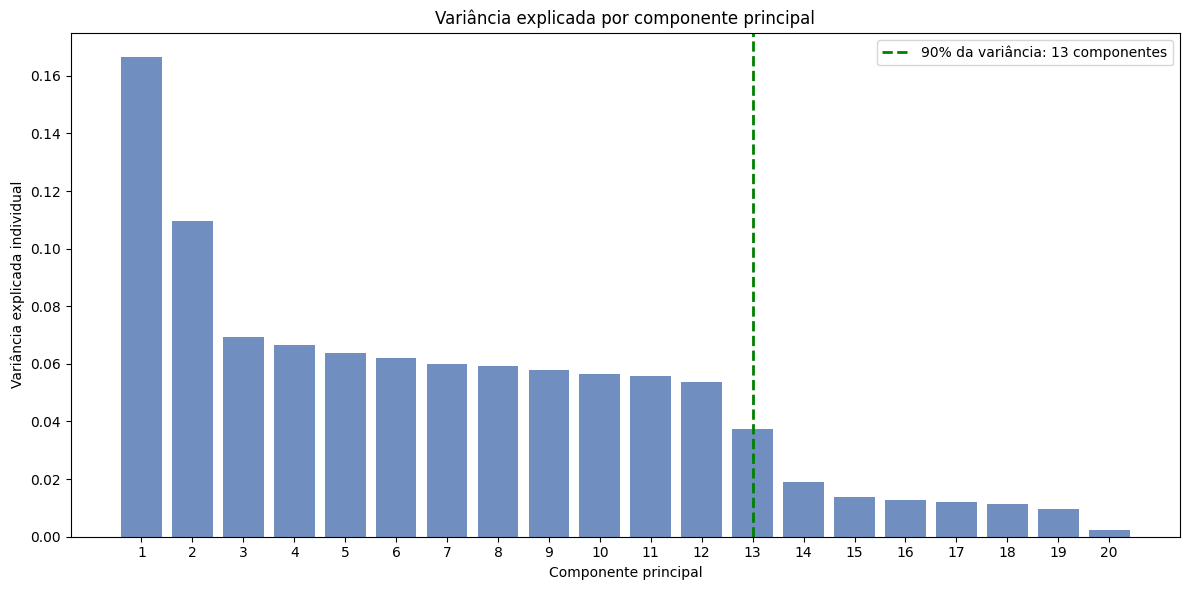

In [18]:
# ================================
# Gráfico: variância individual + linha vertical de 90%
# ================================
componentes_90 = np.argmax(variancia_acumulada >= 0.90) + 1

plt.figure(figsize=(12, 6))

plt.bar(
    resultado_pca["componente"],
    resultado_pca["variancia_explicada"],
    color="#4C72B0",
    alpha=0.8
)

plt.axvline(
    x=componentes_90,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"90% da variância: {componentes_90} componentes"
)

plt.title("Variância explicada por componente principal")
plt.xlabel("Componente principal")
plt.ylabel("Variância explicada individual")
plt.xticks(resultado_pca["componente"])
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
pca_final = PCA(n_components=12)

X_treino_pca_final = pca_final.fit_transform(X_treino)
X_teste_pca_final = pca_final.transform(X_teste)

In [20]:
print(
    f"Quantidade original de variáveis: "
    f"{X_treino.shape[1]}"
)

print(
    f"Quantidade final de componentes: "
    f"{X_treino_pca_final.shape[1]}"
)

print(
    f"Variância total preservada: "
    f"{pca_final.explained_variance_ratio_.sum():.2%}"
)

Quantidade original de variáveis: 20
Quantidade final de componentes: 12
Variância total preservada: 88.16%


### Comparação entre PCA e Kernel PCA

Além do PCA tradicional, também será aplicado o Kernel PCA com kernel RBF, capaz de representar relações não lineares entre as variáveis.

As duas técnicas utilizarão 12 componentes, permitindo comparar os modelos de clusterização sob a mesma quantidade de dimensões.

A partir dessas duas representações, serão avaliados K-Means, DBSCAN e modelos hierárquicos, verificando qual combinação apresenta melhor separação entre os grupos e maior utilidade para a interpretação dos clientes.

In [21]:
from sklearn.decomposition import KernelPCA

# ================================
# Kernel PCA
# ================================
kernel_pca = KernelPCA(
    n_components=12,
    kernel="rbf",
    random_state=42
)

X_treino_kpca = kernel_pca.fit_transform(
    X_treino
)

X_teste_kpca = kernel_pca.transform(
    X_teste
)

In [22]:
# ================================
# Bases para comparação
# ================================
bases_clusterizacao = {
    "PCA": np.asarray(X_treino_pca_final),
    "Kernel PCA": np.asarray(X_treino_kpca)
}

## 7. Modelo K-Means

Nesta etapa, o K-Means será avaliado utilizando duas representações dos dados: PCA tradicional e Kernel PCA.

Para cada abordagem, serão testadas diferentes quantidades de clusters, entre 2 e 10. O desempenho será analisado por meio do Silhouette Score e da distribuição dos clientes em cada grupo.

A comparação permitirá verificar qual técnica de redução de dimensionalidade favorece uma segmentação mais consistente e interpretável.

### K-Means com PCA

Primeiramente, o K-Means será aplicado sobre as 12 componentes geradas pelo PCA tradicional.

Os resultados indicaram melhor Silhouette Score com dois clusters. Entretanto, também foram avaliadas configurações com mais grupos para verificar o equilíbrio entre a separação matemática e a utilidade dos segmentos.

Além da métrica de silhueta, foi analisada a quantidade de clientes em cada cluster, evitando selecionar configurações excessivamente desbalanceadas.

In [23]:
# ================================
# K-Means com PCA
# ================================
print("PCA")

for k in range(2, 11):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    score = silhouette_score(
        X_treino_pca_final,
        labels
    )

    print(f"k={k} -> {score:.4f}")

PCA
k=2 -> 0.1257
k=3 -> 0.1148
k=4 -> 0.1065
k=5 -> 0.0978
k=6 -> 0.0928
k=7 -> 0.0895
k=8 -> 0.0835
k=9 -> 0.0872
k=10 -> 0.0795


In [24]:
# ================================
# Quantidade por cluster - PCA
# ================================
for k in range(2, 11):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    print(f"\nQuantidade de clusters: {k}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


Quantidade de clusters: 2
0     767
1    1233
Name: count, dtype: int64

Quantidade de clusters: 3
0    709
1    746
2    545
Name: count, dtype: int64

Quantidade de clusters: 4
0    458
1    707
2    460
3    375
Name: count, dtype: int64

Quantidade de clusters: 5
0    702
1    259
2    456
3    334
4    249
Name: count, dtype: int64

Quantidade de clusters: 6
0    270
1    117
2    399
3    388
4    399
5    427
Name: count, dtype: int64

Quantidade de clusters: 7
0    113
1    529
2    224
3    237
4    433
5    204
6    260
Name: count, dtype: int64

Quantidade de clusters: 8
0    228
1    200
2    280
3    273
4    238
5    275
6    109
7    397
Name: count, dtype: int64

Quantidade de clusters: 9
0    153
1    228
2    369
3    222
4    298
5    203
6    104
7    308
8    115
Name: count, dtype: int64

Quantidade de clusters: 10
0    117
1     96
2    241
3    169
4    211
5    350
6    234
7    197
8    225
9    160
Name: count, dtype: int64


### K-Means com Kernel PCA

Em seguida, o K-Means foi aplicado sobre as 12 componentes geradas pelo Kernel PCA com kernel RBF.

Essa abordagem apresentou resultados ligeiramente superiores ao PCA tradicional, especialmente nas configurações com três e quatro clusters.

O maior Silhouette Score foi obtido com quatro clusters. Entretanto, a configuração com três grupos apresentou desempenho muito próximo e distribuição suficientemente equilibrada, tornando-se também relevante para a interpretação dos perfis de clientes.

In [25]:
# ================================
# K-Means com Kernel PCA
# ================================
print("Kernel PCA")

for k in range(2, 11):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    score = silhouette_score(
        X_treino_kpca,
        labels
    )

    print(f"k={k} -> {score:.4f}")

Kernel PCA
k=2 -> 0.1238
k=3 -> 0.1437
k=4 -> 0.1465
k=5 -> 0.1397
k=6 -> 0.1301
k=7 -> 0.1287
k=8 -> 0.1274
k=9 -> 0.1093
k=10 -> 0.1222


In [26]:
# ================================
# Quantidade por cluster - Kernel PCA
# ================================
for k in range(2, 11):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    print(f"\nQuantidade de clusters: {k}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


Quantidade de clusters: 2
0    1269
1     731
Name: count, dtype: int64

Quantidade de clusters: 3
0    933
1    715
2    352
Name: count, dtype: int64

Quantidade de clusters: 4
0    487
1    483
2    678
3    352
Name: count, dtype: int64

Quantidade de clusters: 5
0    471
1    336
2    352
3    356
4    485
Name: count, dtype: int64

Quantidade de clusters: 6
0    363
1    252
2    332
3    352
4    439
5    262
Name: count, dtype: int64

Quantidade de clusters: 7
0    171
1    248
2    243
3    311
4    348
5    401
6    278
Name: count, dtype: int64

Quantidade de clusters: 8
0    247
1    164
2    390
3    173
4    348
5    235
6    240
7    203
Name: count, dtype: int64

Quantidade de clusters: 9
0    231
1    169
2    193
3    207
4    196
5    247
6    387
7    149
8    221
Name: count, dtype: int64

Quantidade de clusters: 10
0    345
1    193
2    230
3    186
4    139
5    202
6    141
7    156
8    163
9    245
Name: count, dtype: int64


### Comparação dos resultados do K-Means

O Kernel PCA apresentou melhor desempenho geral do que o PCA tradicional, indicando que a transformação não linear contribuiu para uma separação mais clara entre os grupos.

Apesar disso, os valores de Silhouette Score permaneceram relativamente baixos, sugerindo que ainda existe sobreposição entre os clusters.

A escolha final não deverá considerar apenas o maior resultado numérico, mas também o equilíbrio dos grupos, a interpretação das características médias e a utilidade dos segmentos para o negócio.

## 8. Modelo DBSCAN

O DBSCAN foi avaliado com as representações geradas pelo PCA tradicional e pelo Kernel PCA.

Como o algoritmo forma grupos com base na densidade, foram testados diferentes valores de `eps`, analisando também a quantidade de registros classificados como ruído.

### DBSCAN com PCA

Com o PCA, valores menores de `eps` classificaram praticamente todos os registros como ruído.

Em configurações intermediárias, o modelo formou muitos clusters pequenos e apresentou Silhouette Score próximo de zero, indicando baixa separação entre os grupos.

In [27]:
# ================================
# DBSCAN com PCA
# ================================
print("PCA")

for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    modelo = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    mascara_validos = labels != -1
    clusters_validos = np.unique(
        labels[mascara_validos]
    )

    if len(clusters_validos) >= 2:
        score = silhouette_score(
            X_treino_pca_final[mascara_validos],
            labels[mascara_validos]
        )

        print(f"eps={eps} -> {score:.4f}")
    else:
        print(
            f"eps={eps} -> Silhueta não disponível"
        )

PCA
eps=1.0 -> Silhueta não disponível
eps=1.5 -> Silhueta não disponível
eps=2.0 -> 0.0196
eps=2.5 -> 0.0042
eps=3.0 -> Silhueta não disponível
eps=4.0 -> Silhueta não disponível


In [28]:
# ================================
# Quantidade por cluster - PCA
# ================================
for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    modelo = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    print(f"\neps: {eps}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


eps: 1.0
-1    2000
Name: count, dtype: int64

eps: 1.5
-1    2000
Name: count, dtype: int64

eps: 2.0
-1     1683
 0      139
 1       10
 2        5
 3       26
 4       16
 5        4
 6        4
 7       20
 8        4
 9       20
 10      16
 11       9
 12       6
 13       5
 14       4
 15       5
 16       6
 17       4
 18       4
 19       5
 20       5
Name: count, dtype: int64

eps: 2.5
-1     422
 0    1567
 1       7
 2       4
Name: count, dtype: int64

eps: 3.0
-1      58
 0    1942
Name: count, dtype: int64

eps: 4.0
-1       4
 0    1996
Name: count, dtype: int64


### DBSCAN com Kernel PCA

Com o Kernel PCA, o comportamento foi semelhante. A maior parte dos registros foi classificada como ruído ou distribuída em pequenos grupos pouco representativos.

Além disso, o Silhouette Score apresentou resultado negativo em uma das configurações avaliadas, indicando baixa coesão dos clusters.

In [29]:
# ================================
# DBSCAN com Kernel PCA
# ================================
print("Kernel PCA")

for eps in [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    modelo = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    mascara_validos = labels != -1
    clusters_validos = np.unique(
        labels[mascara_validos]
    )

    if len(clusters_validos) >= 2:
        score = silhouette_score(
            X_treino_kpca[mascara_validos],
            labels[mascara_validos]
        )

        print(f"eps={eps} -> {score:.4f}")
    else:
        print(
            f"eps={eps} -> Silhueta não disponível"
        )

Kernel PCA
eps=0.1 -> Silhueta não disponível
eps=0.2 -> Silhueta não disponível
eps=0.3 -> -0.1310
eps=0.5 -> Silhueta não disponível
eps=0.8 -> Silhueta não disponível
eps=1.0 -> Silhueta não disponível


In [30]:
# ================================
# Quantidade por cluster - Kernel PCA
# ================================
for eps in [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    modelo = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    print(f"\neps: {eps}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


eps: 0.1
-1    2000
Name: count, dtype: int64

eps: 0.2
-1    1992
 0       8
Name: count, dtype: int64

eps: 0.3
-1     1469
 0      436
 1        5
 2        5
 3       10
 4        5
 5        5
 6        5
 7        5
 8        5
 9       10
 10       4
 11       4
 12       5
 13       4
 14       5
 15       5
 16       4
 17       5
 18       4
Name: count, dtype: int64

eps: 0.5
0    2000
Name: count, dtype: int64

eps: 0.8
0    2000
Name: count, dtype: int64

eps: 1.0
0    2000
Name: count, dtype: int64


### Resultado do DBSCAN

Nas duas representações, o DBSCAN não encontrou uma estrutura de densidade estável e interpretável.

Por esse motivo, o modelo não foi considerado adequado para a segmentação desta base.

## 9. Modelos Hierárquicos

Nesta etapa, os modelos hierárquicos serão avaliados utilizando as representações geradas pelo PCA tradicional e pelo Kernel PCA.

Serão comparados os métodos de ligação `single`, `complete`, `average` e `ward`, considerando o Silhouette Score e a distribuição dos clientes entre os clusters.

### Modelos Hierárquicos com PCA

Com o PCA tradicional, os métodos `single` e `average` apresentaram os maiores valores de Silhouette Score.

Entretanto, ambos formaram clusters extremamente desbalanceados, com apenas uma observação em um dos grupos. O método `complete` também apresentou forte desequilíbrio.

O método `ward` apresentou uma silhueta menor, mas gerou uma divisão mais equilibrada entre os clientes, tornando o resultado mais útil para interpretação.

In [31]:
# ================================
# Modelos hierárquicos com PCA
# ================================
print("PCA")

for metodo in ["single", "complete", "average", "ward"]:
    modelo = AgglomerativeClustering(
        n_clusters=2,
        linkage=metodo
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    score = silhouette_score(
        X_treino_pca_final,
        labels
    )

    print(f"{metodo:10s} -> {score:.4f}")

PCA
single     -> 0.4244
complete   -> 0.1291
average    -> 0.4244
ward       -> 0.1086


In [32]:
# ================================
# Quantidade por cluster - PCA
# ================================
for metodo in ["single", "complete", "average", "ward"]:
    modelo = AgglomerativeClustering(
        n_clusters=2,
        linkage=metodo
    )

    labels = modelo.fit_predict(
        X_treino_pca_final
    )

    print(f"\nMétodo: {metodo}")
    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


Método: single
0    1999
1       1
Name: count, dtype: int64

Método: complete
0    1940
1      60
Name: count, dtype: int64

Método: average
0    1999
1       1
Name: count, dtype: int64

Método: ward
0    1357
1     643
Name: count, dtype: int64


### Modelos Hierárquicos com Kernel PCA

Com o Kernel PCA, os métodos `average` e `ward` apresentaram os resultados mais consistentes.

O método `average` obteve a maior silhueta, enquanto o `ward` produziu a distribuição mais equilibrada entre os dois clusters.

Essa configuração apresentou maior potencial para separar clientes com comportamentos distintos sem criar grupos muito pequenos.

In [33]:
# ================================
# Modelos hierárquicos com Kernel PCA
# ================================
print("Kernel PCA")

for metodo in ["single", "complete", "average", "ward"]:
    modelo = AgglomerativeClustering(
        n_clusters=2,
        linkage=metodo
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    score = silhouette_score(
        X_treino_kpca,
        labels
    )

    print(f"{metodo:10s} -> {score:.4f}")

Kernel PCA
single     -> 0.0285
complete   -> 0.0859
average    -> 0.1168
ward       -> 0.1102


In [34]:
# ================================
# Quantidade por cluster - Kernel PCA
# ================================
for metodo in ["single", "complete", "average", "ward"]:
    modelo = AgglomerativeClustering(
        n_clusters=2,
        linkage=metodo
    )

    labels = modelo.fit_predict(
        X_treino_kpca
    )

    print(f"\nMétodo: {metodo}")
    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


Método: single
0    1999
1       1
Name: count, dtype: int64

Método: complete
0    1463
1     537
Name: count, dtype: int64

Método: average
0    1320
1     680
Name: count, dtype: int64

Método: ward
0     852
1    1148
Name: count, dtype: int64


### Comparação dos Resultados Hierárquicos

Apesar de alguns métodos apresentarem Silhouette Score mais elevado, os resultados precisaram ser analisados em conjunto com o tamanho dos clusters.

Considerando o equilíbrio dos grupos e a facilidade de interpretação, a combinação entre Kernel PCA e método `ward` apresentou o resultado mais adequado entre os modelos hierárquicos.

## 10. Comparação dos modelos selecionados

Após a avaliação dos algoritmos, foram selecionadas as duas configurações com maior potencial de interpretação:

- K-Means com Kernel PCA e três clusters;
- Clusterização Hierárquica com Kernel PCA e método Ward, utilizando dois clusters.

A comparação considerou o Silhouette Score, a distribuição dos clientes entre os grupos e as características médias de cada segmento.

O K-Means apresentou o maior Silhouette Score, com três grupos relativamente equilibrados. Já o modelo hierárquico apresentou uma divisão mais simples em dois segmentos, facilitando a identificação de clientes com comportamento mais estável e clientes que exigem maior atenção.

Na próxima etapa, os dois modelos serão analisados graficamente para avaliar a separação visual dos clusters e apoiar a escolha da solução final.

In [35]:
# ================================
# K-Means + Kernel PCA
# ================================
modelo_kmeans_final = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=42
)

labels_kmeans_final = modelo_kmeans_final.fit_predict(
    X_treino_kpca
)

score_kmeans_final = silhouette_score(
    X_treino_kpca,
    labels_kmeans_final
)

In [36]:
# ================================
# Hierárquico + Kernel PCA + Ward
# ================================
modelo_hierarquico_final = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels_hierarquico_final = modelo_hierarquico_final.fit_predict(
    X_treino_kpca
)

score_hierarquico_final = silhouette_score(
    X_treino_kpca,
    labels_hierarquico_final
)

In [37]:
# ================================
# Comparação das métricas
# ================================
comparacao_modelos = pd.DataFrame({
    "modelo": [
        "K-Means + Kernel PCA",
        "Hierárquico + Kernel PCA + Ward"
    ],
    "numero_clusters": [
        len(np.unique(labels_kmeans_final)),
        len(np.unique(labels_hierarquico_final))
    ],
    "silhouette_score": [
        score_kmeans_final,
        score_hierarquico_final
    ],
    "menor_cluster": [
        pd.Series(labels_kmeans_final).value_counts().min(),
        pd.Series(labels_hierarquico_final).value_counts().min()
    ],
    "maior_cluster": [
        pd.Series(labels_kmeans_final).value_counts().max(),
        pd.Series(labels_hierarquico_final).value_counts().max()
    ]
})

comparacao_modelos.round(4)

,modelo,numero_clusters,silhouette_score,menor_cluster,maior_cluster
0,K-Means + Kernel PCA,3,0.1437,352,933
1,Hierárquico + Kernel PCA + Ward,2,0.1102,852,1148


In [38]:
# ================================
# Distribuição dos clusters
# ================================
print("K-Means + Kernel PCA")
print(
    pd.Series(labels_kmeans_final)
    .value_counts()
    .sort_index()
)

print("\nHierárquico + Kernel PCA + Ward")
print(
    pd.Series(labels_hierarquico_final)
    .value_counts()
    .sort_index()
)

K-Means + Kernel PCA
0    933
1    715
2    352
Name: count, dtype: int64

Hierárquico + Kernel PCA + Ward
0     852
1    1148
Name: count, dtype: int64


In [39]:
# ================================
# Perfil dos clusters - K-Means
# ================================
dados_kmeans = dados_treino.copy()
dados_kmeans["cluster"] = labels_kmeans_final

perfil_kmeans = (
    dados_kmeans
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

perfil_kmeans

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente
cluster,,,,,,,,,,,,,,,,
0,43.17,61.91,420.37,3.50,29.02,5.81,7.86,2.49,38.12,2.01,0.99,4.69,4.00,0.73,0.00,1.00
1,43.69,60.50,438.67,3.40,29.62,6.14,8.20,2.14,38.17,2.00,2.73,6.63,5.52,0.64,0.94,1.00
2,43.12,61.63,466.40,3.38,32.37,5.95,8.20,1.48,37.22,2.01,0.35,5.26,1.61,0.43,0.02,0.01


In [40]:
# ================================
# Perfil dos clusters - Hierárquico
# ================================
dados_hierarquico = dados_treino.copy()
dados_hierarquico["cluster"] = labels_hierarquico_final

perfil_hierarquico = (
    dados_hierarquico
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

perfil_hierarquico

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente
cluster,,,,,,,,,,,,,,,,
0,43.32,61.85,437.89,3.48,33.06,6.00,8.07,1.07,38.08,2.01,1.26,5.45,3.35,0.18,0.29,0.59
1,43.37,60.99,432.88,3.42,27.43,5.92,8.02,3.02,37.91,2.01,1.68,5.51,4.70,0.99,0.38,1.00


### Análise dos perfis encontrados

Embora o K-Means tenha apresentado um Silhouette Score ligeiramente superior, a análise das médias mostrou que seus três clusters possuem algumas características próximas entre si.

Já o modelo hierárquico com Kernel PCA e método Ward produziu uma divisão mais clara em dois perfis. Um dos grupos concentra clientes com menor atraso, menos reclamações e menor necessidade de atendimento, enquanto o outro reúne clientes com maior incidência de problemas operacionais.

Por esse motivo, o modelo hierárquico apresentou uma segmentação mais simples, coerente e útil para o objetivo do projeto, facilitando a identificação de clientes estáveis e clientes que exigem maior atenção.

### Comparação visual dos modelos

A projeção em duas dimensões reforça as diferenças entre as duas abordagens avaliadas.

O K-Means formou três grupos visualmente distintos, porém parte dessa separação também fragmentou clientes com características semelhantes em segmentos diferentes.

Já o modelo hierárquico com Kernel PCA e método Ward apresentou uma divisão mais simples em dois grupos, separando de forma mais clara clientes com comportamento mais estável daqueles que concentram maior incidência de atrasos, reclamações e necessidade de atendimento.

Embora o gráfico represente apenas duas dimensões dos dados, ele confirma a maior coerência do modelo hierárquico para o objetivo do projeto. Por isso, essa abordagem foi considerada mais adequada para identificar clientes que exigem maior atenção.

In [41]:
# ================================
# Projeção em 2D para visualização
# ================================
pca_visualizacao = PCA(
    n_components=2
)

X_visualizacao = pca_visualizacao.fit_transform(
    X_treino
)

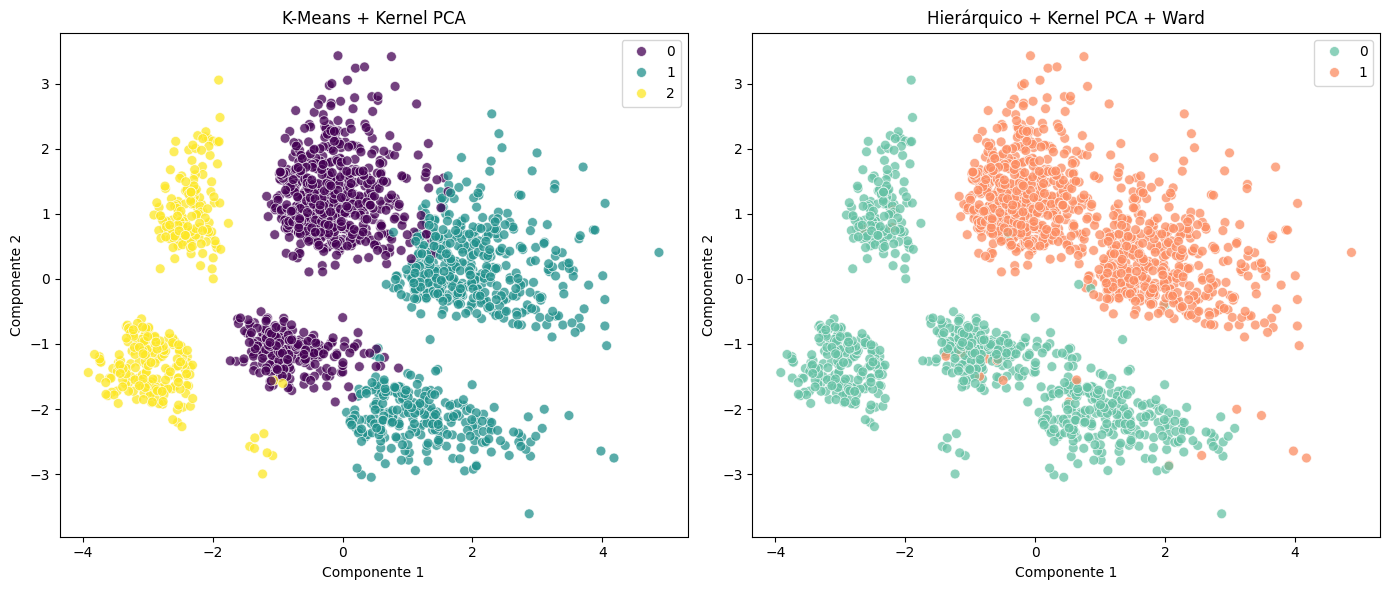

In [42]:
# ================================
# Comparação visual dos clusters
# ================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# K-Means
sns.scatterplot(
    x=X_visualizacao[:, 0],
    y=X_visualizacao[:, 1],
    hue=labels_kmeans_final,
    palette="viridis",
    s=50,
    alpha=0.75,
    ax=axes[0]
)

axes[0].set_title(
    "K-Means + Kernel PCA"
)

axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")

# Hierárquico
sns.scatterplot(
    x=X_visualizacao[:, 0],
    y=X_visualizacao[:, 1],
    hue=labels_hierarquico_final,
    palette="Set2",
    s=50,
    alpha=0.75,
    ax=axes[1]
)

axes[1].set_title(
    "Hierárquico + Kernel PCA + Ward"
)

axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")

plt.tight_layout()
plt.show()

## 11. Definição do modelo final

Após a comparação dos algoritmos, foi selecionada a combinação entre Kernel PCA e Clusterização Hierárquica com método Ward.

Embora o K-Means tenha apresentado um Silhouette Score ligeiramente superior, o modelo hierárquico produziu dois grupos mais equilibrados, coerentes com o objetivo do projeto e mais fáceis de interpretar.

A segmentação final busca distinguir clientes de menor criticidade daqueles que concentram maior incidência de atrasos, reclamações e dificuldades no atendimento.

O modelo final apresentou Silhouette Score de 0,1102, indicando que ainda existe sobreposição entre os grupos. Apesar disso, a divisão em dois clusters apresentou maior utilidade prática para priorização e acompanhamento dos clientes.

In [43]:
# ================================
# Modelo final de clusterização
# ================================

modelo_cluster_final = AgglomerativeClustering(n_clusters=2, linkage="ward")

labels_cluster_final = modelo_cluster_final.fit_predict(X_treino_kpca)

silhueta_final = silhouette_score(X_treino_kpca, labels_cluster_final)

print(f'Silhouette Score: {silhueta_final:.4f}')

print("\nQuantidade de clientes por cluster: ")
print(
    pd.Series(labels_cluster_final).value_counts().sort_index()
)

Silhouette Score: 0.1102

Quantidade de clientes por cluster: 
0     852
1    1148
Name: count, dtype: int64


## 12. Perfil e identificação dos clusters

Nesta etapa, os rótulos gerados pelo modelo serão associados aos dados originais de treino para permitir a interpretação das características de cada grupo.

Como os números dos clusters são apenas identificadores, os segmentos serão definidos a partir das médias das variáveis relacionadas a atrasos, atendimento, tempo de resolução e recorrência de reclamações.

A análise mostrou que um dos grupos concentra maiores níveis de criticidade operacional, enquanto o outro apresenta indicadores relativamente mais baixos. Por esse motivo, os segmentos foram nomeados como **Clientes de alta criticidade** e **Clientes de menor criticidade**.

Essa nomeação é relativa ao comportamento observado na base e não significa que o grupo de menor criticidade esteja livre de problemas, mas apenas que apresenta menor intensidade de falhas quando comparado ao outro segmento.

In [44]:
# ================================
# Associação dos clusters à base
# ================================

dados_cluster_final = dados_treino.copy()

dados_cluster_final['cluster'] = labels_cluster_final

In [45]:
# ================================
# Perfil médio dos clusters
# ================================

perfil_clusters_final = (
    dados_cluster_final
    .groupby("cluster")
    .agg(
        quantidade_clientes=("cluster", "size"),
        valor_pedido_medio=("valor_pedido", "mean"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        atraso_medio=("atraso_entrega_dias", "mean"),
        contatos_medios=("contatos_atendimento", "mean"),
        tempo_resolucao_medio=("tempo_resolucao_dias", "mean"),
        reclamacoes_medias=("numero_reclamacoes", "mean"),
        atraso_critico=("atraso_critico", "mean"),
        problema_complexo=("problema_complexo", "mean"),
        reclamacao_recorrente=("reclamacao_recorrente", "mean")
    )
    .round(2)
)

perfil_clusters_final

,quantidade_clientes,valor_pedido_medio,tempo_entrega_medio,atraso_medio,contatos_medios,tempo_resolucao_medio,reclamacoes_medias,atraso_critico,problema_complexo,reclamacao_recorrente
cluster,,,,,,,,,,
0,852,437.89,8.07,1.07,1.26,5.45,3.35,0.18,0.29,0.59
1,1148,432.88,8.02,3.02,1.68,5.51,4.70,0.99,0.38,1.00


In [46]:
# ================================
# Identificação do cluster de atenção
# ================================
variaveis_atencao = [
    "atraso_entrega_dias",
    "contatos_atendimento",
    "tempo_resolucao_dias",
    "numero_reclamacoes"
]

indice_atencao = (
    dados_cluster_final
    .groupby("cluster")[variaveis_atencao]
    .mean()
    .rank(pct=True)
    .mean(axis=1)
)

cluster_atencao = indice_atencao.idxmax()
cluster_estavel = indice_atencao.idxmin()

nomes_clusters = {
    cluster_estavel: "Clientes de menor criticidade",
    cluster_atencao: "Clientes de alta criticidade"
}

dados_cluster_final["segmento"] = (
    dados_cluster_final["cluster"]
    .map(nomes_clusters)
)

dados_cluster_final[
    ["cluster", "segmento"]
].value_counts()

,,count
cluster,segmento,
1,Clientes de alta criticidade,1148
0,Clientes de menor criticidade,852


In [47]:
# ================================
# Perfil final por segmento
# ================================
perfil_segmentos = (
    dados_cluster_final
    .groupby("segmento")
    .agg(
        quantidade_clientes=("segmento", "size"),
        valor_pedido_medio=("valor_pedido", "mean"),
        atraso_medio=("atraso_entrega_dias", "mean"),
        contatos_medios=("contatos_atendimento", "mean"),
        tempo_resolucao_medio=("tempo_resolucao_dias", "mean"),
        reclamacoes_medias=("numero_reclamacoes", "mean"),
        percentual_atraso_critico=("atraso_critico", "mean"),
        percentual_problema_complexo=("problema_complexo", "mean"),
        percentual_reclamacao_recorrente=(
            "reclamacao_recorrente",
            "mean"
        )
    )
    .round(2)
)

perfil_segmentos

,quantidade_clientes,valor_pedido_medio,atraso_medio,contatos_medios,tempo_resolucao_medio,reclamacoes_medias,percentual_atraso_critico,percentual_problema_complexo,percentual_reclamacao_recorrente
segmento,,,,,,,,,
Clientes de alta criticidade,1148,432.88,3.02,1.68,5.51,4.70,0.99,0.38,1.00
Clientes de menor criticidade,852,437.89,1.07,1.26,5.45,3.35,0.18,0.29,0.59


## 14. Relação dos segmentos com o NPS

O NPS não foi utilizado durante a formação dos clusters. Nesta etapa, ele será incluído apenas como variável de validação, permitindo verificar se os segmentos encontrados também apresentam diferenças relevantes de satisfação.

Os resultados mostram que o grupo de **alta criticidade** possui NPS médio de 3,29 e concentra 90,68% de clientes detratores, com participação praticamente inexistente de promotores.

Já o grupo de **menor criticidade** apresentou NPS médio de 5,86, além de maior presença de clientes neutros e promotores. Ainda assim, 52,46% desse segmento também foi classificado como detrator.

Essa análise reforça que os clusters não representam uma separação perfeita entre clientes satisfeitos e insatisfeitos. Entretanto, o modelo conseguiu identificar um grupo significativamente mais vulnerável, com maior concentração de problemas operacionais e menor nível de satisfação.

Dessa forma, os segmentos devem ser interpretados em termos relativos: clientes de alta criticidade exigem atuação prioritária, enquanto clientes de menor criticidade apresentam uma situação menos severa, mas ainda demandam monitoramento.

In [48]:
# ================================
# Inclusão do NPS
# ================================
dados_cluster_final["nps"] = dados.loc[
    dados_cluster_final.index,
    "nps"
]

In [49]:
# ================================
# Classificação tradicional do NPS
# ================================
def classificar_nps(nota):
    if nota <= 6:
        return "Detrator"

    if nota <= 8:
        return "Neutro"

    return "Promotor"


dados_cluster_final["classe_nps"] = (
    dados_cluster_final["nps"]
    .apply(classificar_nps)
)

In [50]:
# ================================
# NPS médio por segmento
# ================================
analise_nps_segmentos = (
    dados_cluster_final
    .groupby("segmento")
    .agg(
        quantidade_clientes=("nps", "size"),
        nps_medio=("nps", "mean"),
        nps_mediano=("nps", "median"),
        nps_minimo=("nps", "min"),
        nps_maximo=("nps", "max")
    )
    .round(2)
)

analise_nps_segmentos

,quantidade_clientes,nps_medio,nps_mediano,nps_minimo,nps_maximo
segmento,,,,,
Clientes de alta criticidade,1148,3.29,3.3,0.0,9.5
Clientes de menor criticidade,852,5.86,5.9,0.0,10.0


In [51]:
# ================================
# Distribuição das classes de NPS
# ================================
distribuicao_nps = pd.crosstab(
    dados_cluster_final["segmento"],
    dados_cluster_final["classe_nps"],
    normalize="index"
).mul(100).round(2)

distribuicao_nps

classe_nps,Detrator,Neutro,Promotor
segmento,,,
Clientes de alta criticidade,90.68,8.36,0.96
Clientes de menor criticidade,52.46,29.81,17.72


## 15. Visualização dos segmentos e do NPS

O gráfico apresenta a distribuição percentual das classes de NPS em cada segmento, facilitando a comparação do nível de satisfação entre os grupos.

O segmento de **alta criticidade** concentra quase exclusivamente clientes detratores, reforçando sua maior vulnerabilidade e a necessidade de atuação prioritária.

Já o segmento de **menor criticidade** apresenta uma composição mais diversificada, com maior participação de clientes neutros e promotores. Mesmo assim, os detratores ainda representam a maior parcela do grupo.

A visualização confirma que a clusterização não separa perfeitamente clientes satisfeitos e insatisfeitos, mas identifica com clareza um segmento com criticidade significativamente maior.

In [52]:
# ================================
# Preparação dos dados para o gráfico
# ================================
distribuicao_nps_grafico = (
    distribuicao_nps
    .reset_index()
    .melt(
        id_vars="segmento",
        var_name="classe_nps",
        value_name="percentual"
    )
)

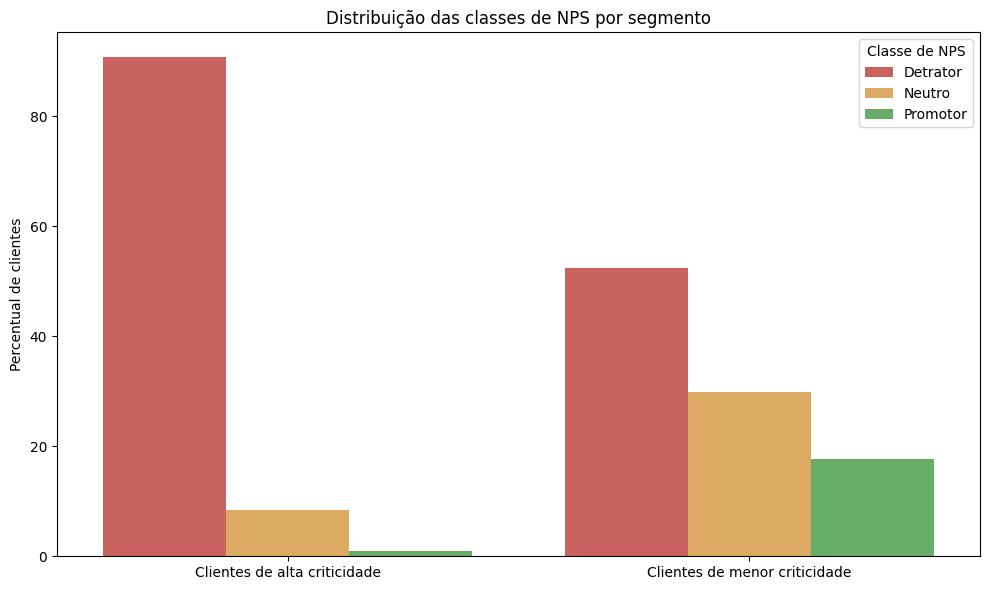

In [53]:
# ================================
# Distribuição do NPS por segmento
# ================================
plt.figure(figsize=(10, 6))

sns.barplot(
    data=distribuicao_nps_grafico,
    x="segmento",
    y="percentual",
    hue="classe_nps",
    palette={
        "Detrator": "#D9534F",
        "Neutro": "#F0AD4E",
        "Promotor": "#5CB85C"
    }
)

plt.title("Distribuição das classes de NPS por segmento")
plt.xlabel("")
plt.ylabel("Percentual de clientes")
plt.legend(title="Classe de NPS")
plt.tight_layout()
plt.show()

## 16. Recomendações de negócio

A segmentação permite direcionar estratégias diferentes de acordo com o nível de criticidade de cada grupo.

Os **clientes de menor criticidade** podem ser acompanhados por ações de relacionamento, fidelização e monitoramento preventivo, buscando preservar a experiência e evitar a evolução de problemas.

Já os **clientes de alta criticidade** devem ser priorizados em iniciativas de recuperação, acompanhamento de reclamações e tratamento de falhas operacionais, principalmente aquelas relacionadas a atrasos, atendimento e recorrência de problemas.

A tabela final reúne as principais informações de cada cliente, permitindo apoiar a priorização das ações e facilitar o uso dos resultados pelas áreas de atendimento, experiência do cliente e relacionamento.

As recomendações apresentadas possuem caráter orientativo e devem ser adaptadas às políticas comerciais, à capacidade operacional e às regras de negócio da empresa.

In [58]:
# ================================
# Recomendações por segmento
# ================================
acoes_segmentos = {
    "Clientes de menor criticidade": (
        "Manter relacionamento, fidelização e monitoramento preventivo"
    ),
    "Clientes de alta criticidade": (
        "Priorizar atendimento, acompanhar reclamações e tratar falhas operacionais"
    )
}

dados_cluster_final["acao_recomendada"] = (
    dados_cluster_final["segmento"]
    .map(acoes_segmentos)
)

In [59]:
# ================================
# Tabela final de segmentação
# ================================
tabela_segmentacao = dados_cluster_final[
    [
        "segmento",
        "nps",
        "classe_nps",
        "valor_pedido",
        "tempo_entrega_dias",
        "atraso_entrega_dias",
        "contatos_atendimento",
        "tempo_resolucao_dias",
        "numero_reclamacoes",
        "atraso_critico",
        "problema_complexo",
        "reclamacao_recorrente",
        "acao_recomendada"
    ]
].copy()

tabela_segmentacao.head()

,segmento,nps,classe_nps,valor_pedido,tempo_entrega_dias,atraso_entrega_dias,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,acao_recomendada
2055,Clientes de alta criticidade,2.5,Detrator,604.69,5,3,2,10,4,1,1,1,"Priorizar atendimento, acompanhar reclamações ..."
1961,Clientes de alta criticidade,4.9,Detrator,162.00,2,2,2,4,4,1,1,1,"Priorizar atendimento, acompanhar reclamações ..."
1864,Clientes de alta criticidade,5.2,Detrator,164.79,6,2,1,0,5,1,0,1,"Priorizar atendimento, acompanhar reclamações ..."
2326,Clientes de menor criticidade,5.6,Detrator,254.79,8,1,0,11,3,0,0,1,"Manter relacionamento, fidelização e monitoram..."
461,Clientes de alta criticidade,0.0,Detrator,222.50,9,5,6,3,10,1,1,1,"Priorizar atendimento, acompanhar reclamações ..."


## 17. Salvamento dos resultados

Nesta etapa, serão salvos a base segmentada e os principais artefatos utilizados no processo de clusterização.

A base final poderá ser reutilizada em análises futuras, dashboards e estratégias de relacionamento com os clientes. Também serão armazenados o pipeline de pré-processamento e o Kernel PCA, garantindo a reprodução das mesmas transformações aplicadas durante o projeto.

O modelo hierárquico será salvo como artefato analítico. Entretanto, como o `AgglomerativeClustering` não possui o método `predict`, ele não permite atribuir diretamente novos clientes aos clusters já formados.

Por esse motivo, sua utilização é mais adequada para análise da base atual. Em uma aplicação futura, a segmentação de novos clientes poderá ser operacionalizada por meio de um modelo auxiliar supervisionado ou pela adoção de um algoritmo com suporte nativo à predição.

In [56]:
# ================================
# Salvamento da base segmentada
# ================================
tabela_segmentacao.to_csv(
    "clientes_segmentados.csv",
    index=False
)

In [57]:
# ================================
# Salvamento dos artefatos
# ================================
joblib.dump(
    full_pipeline,
    "pre_processamento_clusterizacao.pkl"
)

joblib.dump(
    kernel_pca,
    "kernel_pca_clusterizacao.pkl"
)

joblib.dump(
    modelo_cluster_final,
    "modelo_hierarquico_ward.pkl"
)

['modelo_hierarquico_ward.pkl']

## Considerações finais

Este notebook apresentou uma análise de segmentação de clientes com técnicas de aprendizado não supervisionado. O objetivo foi identificar grupos com diferentes níveis de criticidade operacional e necessidade de acompanhamento.

Após o pré-processamento dos dados, foram comparadas duas técnicas de redução de dimensionalidade: PCA tradicional e Kernel PCA. Em seguida, os algoritmos K-Means, DBSCAN e Clusterização Hierárquica foram avaliados por meio do Silhouette Score, da distribuição dos clientes entre os grupos e da capacidade de gerar segmentos interpretáveis.

O DBSCAN não encontrou uma estrutura de densidade consistente, formando muitos pontos de ruído ou pequenos grupos pouco representativos. O K-Means apresentou o maior Silhouette Score, porém seus clusters possuíam perfis parcialmente semelhantes.

A combinação entre Kernel PCA e Clusterização Hierárquica com método Ward foi selecionada como solução final. Mesmo com um Silhouette Score baixo, essa configuração gerou dois grupos mais equilibrados, simples de interpretar e coerentes com o objetivo do projeto.

Os segmentos foram definidos como **Clientes de menor criticidade** e **Clientes de alta criticidade**, considerando indicadores como atraso na entrega, contatos com o atendimento, tempo de resolução e recorrência de reclamações.

A análise posterior do NPS reforçou essa interpretação. O grupo de alta criticidade apresentou menor NPS médio e maior concentração de detratores. Já o grupo de menor criticidade demonstrou uma situação menos severa, embora ainda reunisse clientes insatisfeitos.

Portanto, a clusterização não produziu uma separação perfeita entre clientes satisfeitos e insatisfeitos. Ainda assim, conseguiu identificar um segmento significativamente mais vulnerável, que pode ser priorizado em ações de recuperação, atendimento e prevenção de novas falhas.

Este notebook complementa o modelo supervisionado desenvolvido anteriormente. Enquanto a classificação estima o risco individual de um cliente se tornar detrator, a clusterização revela perfis com diferentes padrões de comportamento e criticidade.

Com isso, o projeto passa a oferecer uma visão mais completa da satisfação dos clientes, apoiando estratégias de retenção, monitoramento preventivo, priorização de atendimento e melhoria da experiência.